# Tangent Planes and Partial Derivatives

A guided notebook on finding the **tangent plane** to a surface.

This notebook explains:

- how tangent lines generalize to tangent planes
- what partial derivatives mean geometrically
- why fixing one variable gives a curve
- how to build the tangent plane formula
- a worked example with $f(x,y)=x^2+y^2$
- Python 3D visualizations
- symbolic checks with SymPy
- practice exercises

This notebook follows the uploaded guidelines template.


## 1. Introduction

In single-variable calculus, the derivative gives the slope of a tangent line.

For a function

$$
y=f(x)
$$

the tangent line approximates the graph near a point.

In multivariable calculus, a function can depend on two inputs:

$$
z=f(x,y)
$$

Its graph is a surface in 3D.

At a point on the surface, the best linear approximation is not a tangent line, but a **tangent plane**.


## 2. Visual Intuition

The image below shows the core idea.

For a surface

$$
z=f(x,y)
$$

we can study two simpler one-variable slices:

- fix $y$ and move in the $x$-direction
- fix $x$ and move in the $y$-direction

Each slice gives a tangent line.

The tangent plane contains both tangent lines.

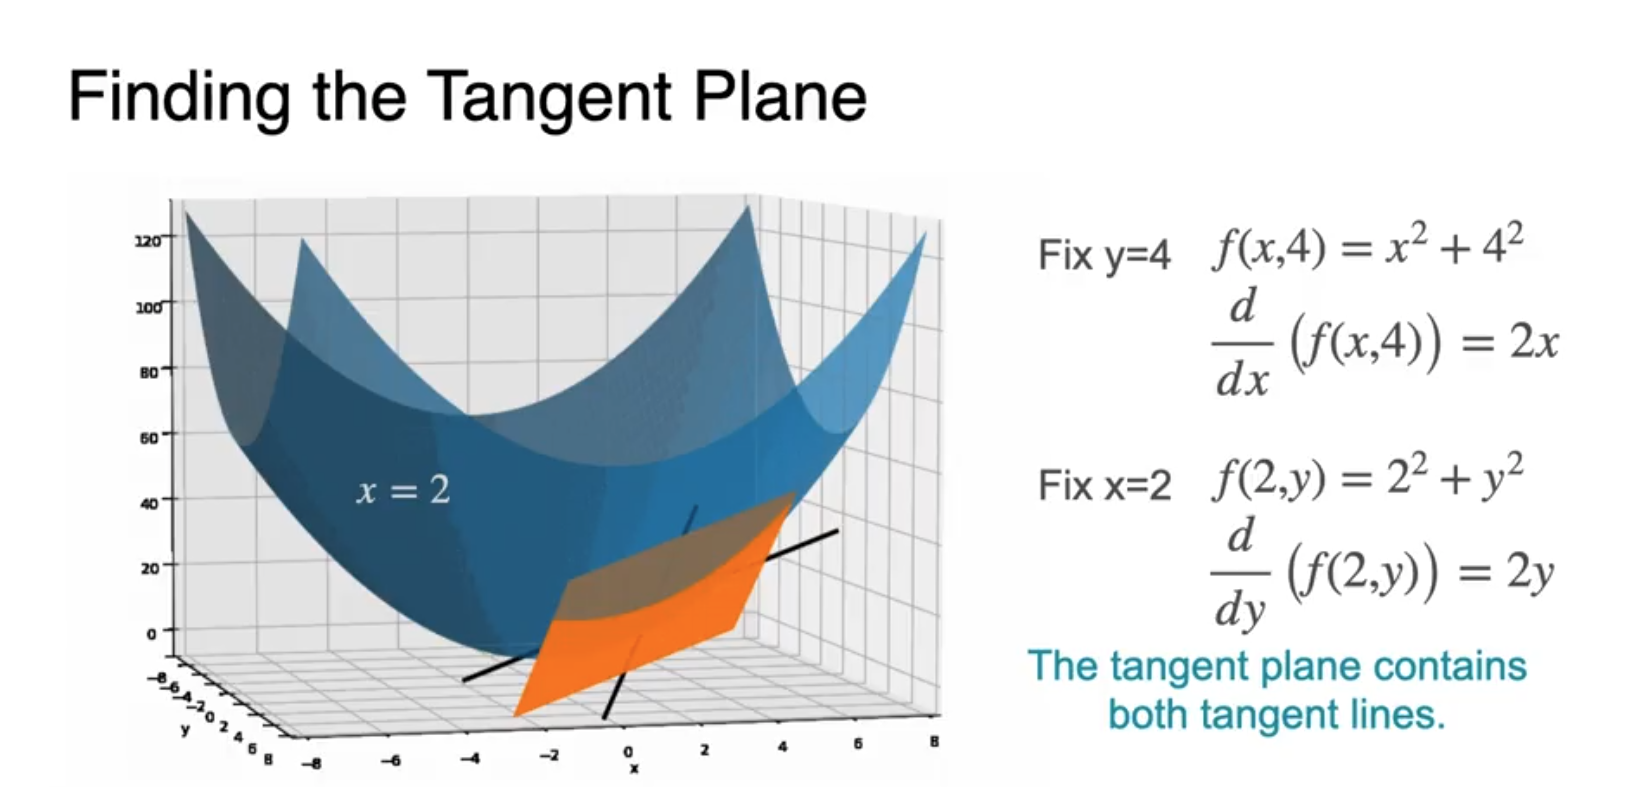


## 3. From Tangent Line to Tangent Plane

For a one-variable function, the tangent line at $x=a$ is:

$$
L(x)=f(a)+f'(a)(x-a)
$$

For a two-variable function, the tangent plane at $(a,b)$ is:

$$
z=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)
$$

Here:

- $f_x(a,b)$ is the slope in the $x$-direction
- $f_y(a,b)$ is the slope in the $y$-direction

These are called **partial derivatives**.


## 4. Partial Derivatives

For a function

$$
f(x,y)
$$

the partial derivative with respect to $x$ is written:

$$
f_x(x,y)
$$

or

$$
\frac{\partial f}{\partial x}
$$

It means:

> differentiate with respect to $x$ while treating $y$ as constant.

Similarly,

$$
f_y(x,y)
$$

or

$$
\frac{\partial f}{\partial y}
$$

means:

> differentiate with respect to $y$ while treating $x$ as constant.


## 5. Example Surface

Use the surface from the slide:

$$
f(x,y)=x^2+y^2
$$

This is a paraboloid.

### Fix $y=4$

Then:

$$
f(x,4)=x^2+4^2=x^2+16
$$

Differentiate with respect to $x$:

$$
\frac{d}{dx}f(x,4)=2x
$$

### Fix $x=2$

Then:

$$
f(2,y)=2^2+y^2=4+y^2
$$

Differentiate with respect to $y$:

$$
\frac{d}{dy}f(2,y)=2y
$$


## 6. Partial Derivatives of the Surface

For

$$
f(x,y)=x^2+y^2
$$

we compute:

$$
f_x(x,y)=2x
$$

and

$$
f_y(x,y)=2y
$$

At the point

$$
(a,b)=(2,4)
$$

we get:

$$
f_x(2,4)=4
$$

and

$$
f_y(2,4)=8
$$

Also:

$$
f(2,4)=2^2+4^2=20
$$


## 7. Tangent Plane Formula

The tangent plane to

$$
z=f(x,y)
$$

at the point $(a,b)$ is:

$$
z=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)
$$

For our example:

$$
f(x,y)=x^2+y^2
$$

at:

$$
(a,b)=(2,4)
$$

we have:

$$
f(2,4)=20
$$

$$
f_x(2,4)=4
$$

$$
f_y(2,4)=8
$$

So the tangent plane is:

$$
z=20+4(x-2)+8(y-4)
$$

Simplify:

$$
z=4x+8y-20
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## 8. Symbolic Derivation with SymPy

In [2]:
x, y = sp.symbols('x y')

f = x**2 + y**2

fx = sp.diff(f, x)
fy = sp.diff(f, y)

a, b = 2, 4

f_ab = f.subs({x: a, y: b})
fx_ab = fx.subs({x: a, y: b})
fy_ab = fy.subs({x: a, y: b})

tangent_plane = f_ab + fx_ab*(x-a) + fy_ab*(y-b)

print("f(x,y) =", f)
print("f_x =", fx)
print("f_y =", fy)
print("f(2,4) =", f_ab)
print("f_x(2,4) =", fx_ab)
print("f_y(2,4) =", fy_ab)
print("Tangent plane =", sp.expand(tangent_plane))


f(x,y) = x**2 + y**2
f_x = 2*x
f_y = 2*y
f(2,4) = 20
f_x(2,4) = 4
f_y(2,4) = 8
Tangent plane = 4*x + 8*y - 20


## 9. 3D Visualization: Surface and Tangent Plane

We now plot:

- the surface $z=x^2+y^2$
- the tangent plane at $(2,4,20)$
- the tangent point


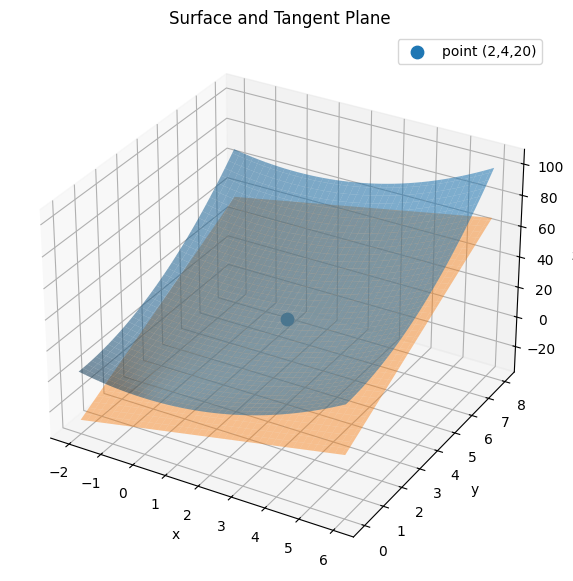

In [3]:
from mpl_toolkits.mplot3d import Axes3D

def surface(x, y):
    return x**2 + y**2

def tangent_plane_func(x, y):
    return 20 + 4*(x - 2) + 8*(y - 4)

x_vals = np.linspace(-2, 6, 80)
y_vals = np.linspace(0, 8, 80)
X, Y = np.meshgrid(x_vals, y_vals)

Z = surface(X, Y)
Z_plane = tangent_plane_func(X, Y)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, alpha=0.55)
ax.plot_surface(X, Y, Z_plane, alpha=0.45)

ax.scatter([2], [4], [20], s=80, label="point (2,4,20)")

ax.set_title("Surface and Tangent Plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.show()


## 10. Tangent Lines Inside the Tangent Plane

The tangent plane contains two important tangent lines:

### $x$-direction tangent line

Fix $y=4$ and move in the $x$-direction.

The line is:

$$
z=20+4(x-2)
$$

### $y$-direction tangent line

Fix $x=2$ and move in the $y$-direction.

The line is:

$$
z=20+8(y-4)
$$

These two lines determine the tangent plane.


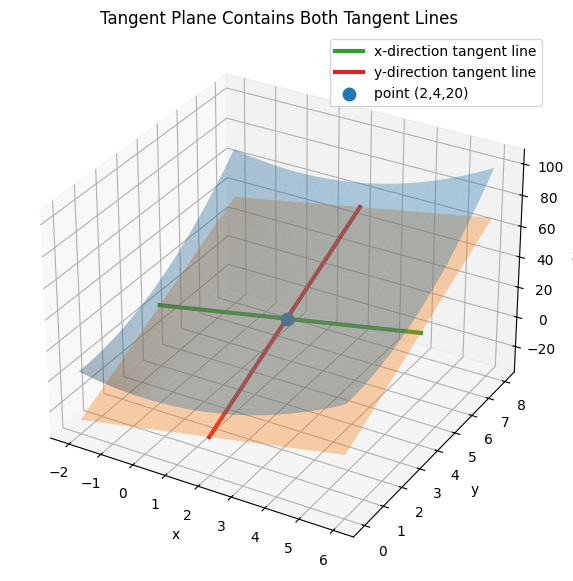

In [4]:
x_line = np.linspace(-2, 6, 100)
y_fixed = np.full_like(x_line, 4)
z_x_line = 20 + 4*(x_line - 2)

y_line = np.linspace(0, 8, 100)
x_fixed = np.full_like(y_line, 2)
z_y_line = 20 + 8*(y_line - 4)

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(X, Y, Z, alpha=0.35)
ax.plot_surface(X, Y, Z_plane, alpha=0.35)

ax.plot(x_line, y_fixed, z_x_line, linewidth=3, label="x-direction tangent line")
ax.plot(x_fixed, y_line, z_y_line, linewidth=3, label="y-direction tangent line")

ax.scatter([2], [4], [20], s=80, label="point (2,4,20)")

ax.set_title("Tangent Plane Contains Both Tangent Lines")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.legend()
plt.show()


## 11. Local Linear Approximation

The tangent plane is the best linear approximation near the point.

For our surface:

$$
f(x,y)=x^2+y^2
$$

the tangent plane approximation near $(2,4)$ is:

$$
L(x,y)=20+4(x-2)+8(y-4)
$$

For points close to $(2,4)$,

$$
f(x,y)\approx L(x,y)
$$


In [5]:
def linear_approximation(x, y):
    return 20 + 4*(x - 2) + 8*(y - 4)

test_points = [
    (2.1, 4.1),
    (1.9, 3.8),
    (2.5, 4.2),
    (3.0, 5.0)
]

for px, py in test_points:
    exact = surface(px, py)
    approx = linear_approximation(px, py)
    error = exact - approx
    print(f"(x,y)=({px:.1f},{py:.1f}) | exact={exact:.4f} | plane={approx:.4f} | error={error:.4f}")


(x,y)=(2.1,4.1) | exact=21.2200 | plane=21.2000 | error=0.0200
(x,y)=(1.9,3.8) | exact=18.0500 | plane=18.0000 | error=0.0500
(x,y)=(2.5,4.2) | exact=23.8900 | plane=23.6000 | error=0.2900
(x,y)=(3.0,5.0) | exact=34.0000 | plane=32.0000 | error=2.0000


## 12. Why the Approximation Works Best Nearby

The tangent plane is a **local approximation**.

That means it is most accurate close to the tangent point.

As we move farther away from $(2,4)$, the surface bends more, and the plane becomes less accurate.


## 13. General Tangent Plane Workflow

To find the tangent plane to $z=f(x,y)$ at $(a,b)$:

1. Compute the point height:

$$
f(a,b)
$$

2. Compute the partial derivatives:

$$
f_x(x,y), \qquad f_y(x,y)
$$

3. Evaluate them at $(a,b)$:

$$
f_x(a,b), \qquad f_y(a,b)
$$

4. Substitute into:

$$
z=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)
$$


## 14. Worked Example 2

Find the tangent plane to:

$$
f(x,y)=xy
$$

at:

$$
(1,3)
$$

### Step 1: Compute height

$$
f(1,3)=1\cdot3=3
$$

### Step 2: Compute partial derivatives

$$
f_x(x,y)=y
$$

$$
f_y(x,y)=x
$$

### Step 3: Evaluate at $(1,3)$

$$
f_x(1,3)=3
$$

$$
f_y(1,3)=1
$$

### Step 4: Tangent plane

$$
z=3+3(x-1)+1(y-3)
$$

Simplify:

$$
z=3x+y-3
$$


## 15. Exercises

### Basic

1. Find $f_x$ and $f_y$ for:

$$
f(x,y)=x^2-y^2
$$

2. Find the tangent plane to:

$$
f(x,y)=x^2+y^2
$$

at $(1,1)$.

### Intermediate

3. Find the tangent plane to:

$$
f(x,y)=xy
$$

at $(2,5)$.

4. Find the tangent plane to:

$$
f(x,y)=x^2+3y^2
$$

at $(1,2)$.

### Advanced

5. Find the tangent plane to:

$$
f(x,y)=\sin(xy)
$$

at $(1,0)$.

6. Explain why the tangent plane contains both coordinate-direction tangent lines.


## 16. Solutions / Checks

### 1.

$$
f_x=2x
$$

$$
f_y=-2y
$$

### 2.

For $f(x,y)=x^2+y^2$ at $(1,1)$:

$$
f(1,1)=2
$$

$$
f_x(1,1)=2
$$

$$
f_y(1,1)=2
$$

So:

$$
z=2+2(x-1)+2(y-1)
$$

### 3.

For $f(x,y)=xy$ at $(2,5)$:

$$
f(2,5)=10
$$

$$
f_x=y \Rightarrow f_x(2,5)=5
$$

$$
f_y=x \Rightarrow f_y(2,5)=2
$$

So:

$$
z=10+5(x-2)+2(y-5)
$$

### 4.

For $f(x,y)=x^2+3y^2$ at $(1,2)$:

$$
f(1,2)=13
$$

$$
f_x=2x \Rightarrow f_x(1,2)=2
$$

$$
f_y=6y \Rightarrow f_y(1,2)=12
$$

So:

$$
z=13+2(x-1)+12(y-2)
$$

### 5.

For $f(x,y)=\sin(xy)$:

$$
f_x=y\cos(xy)
$$

$$
f_y=x\cos(xy)
$$

At $(1,0)$:

$$
f(1,0)=0
$$

$$
f_x(1,0)=0
$$

$$
f_y(1,0)=1
$$

So:

$$
z=y
$$

### 6.

Fixing one variable gives a one-dimensional curve on the surface. The tangent line to that curve describes the slope in one coordinate direction. The tangent plane is the unique plane that matches both coordinate-direction slopes at the point.


## 17. Conclusion

A tangent plane is the multivariable version of a tangent line.

For a surface:

$$
z=f(x,y)
$$

the tangent plane at $(a,b)$ is:

$$
z=f(a,b)+f_x(a,b)(x-a)+f_y(a,b)(y-b)
$$

Key intuition:

- $f_x$ measures slope in the $x$-direction
- $f_y$ measures slope in the $y$-direction
- fixing one variable gives a curve on the surface
- the tangent plane contains the tangent lines from these slices

For the example:

$$
f(x,y)=x^2+y^2
$$

at $(2,4)$, the tangent plane is:

$$
z=20+4(x-2)+8(y-4)
$$

or:

$$
z=4x+8y-20
$$
